In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/home/duarte/Desktop/PeakStone/Multichemistry/mpc_251227')
from load_data import load_cell_data, load_energy_data_household, load_energy_data_fast_regulation
import matplotlib.pyplot as plt


def get_battery_parameters(n_cells: dict, cells_df: pd.DataFrame) -> pd.DataFrame:
    # Copiar para não alterar o DataFrame original
    bat_df = cells_df.copy()

    # Inicializar colunas
    bat_df["n_cells"] = 0
    bat_df["P_dis_max"] = 0.0
    bat_df["P_ch_max"] = 0.0
    bat_df["E_total_Wh"] = 0.0

    for idx, row in bat_df.iterrows():
        chem = row["Composition"]
        n = n_cells.get(chem, 0)

        bat_df.at[idx, "n_cells"] = n
        bat_df.at[idx, "P_dis_max"] = row["P_dis_cell_max"] * n
        bat_df.at[idx, "P_ch_max"] = row["P_ch_cell_max"] * n
        bat_df.at[idx, "E_total_Wh"] = row["E_cell_Wh"] * n

    return bat_df


def dispatch_battery(df, bat_df, dt, eff=0.9):
    """
    Dispatch battery with round-trip efficiency (eff).
    eff: charging/discharging efficiency (0 < eff <= 1), default 0.9 (90%)
    Optimized for cases where P_load_inst_kW and P_pv_inst_kW are often zero.
    """
    n = len(df)
    P_batt = {row["Composition"]: np.zeros(n) for _, row in bat_df.iterrows()}
    SOC_hist = {row["Composition"]: np.zeros(n) for _, row in bat_df.iterrows()}
    SOC = {
        row["Composition"]: 0.75 * row["E_total_Wh"] / 1000
        for _, row in bat_df.iterrows()
    }
    P_grid = np.zeros(n)

    # Pre-extract arrays for speed
    P_pv = df["P_pv_inst_kW"].values
    P_load = df["P_load_inst_kW"].values

    for t in range(n):
        # Skip if both are zero (no action needed)
        if P_pv[t] == 0 and P_load[t] == 0:
            for chem in SOC_hist:
                SOC_hist[chem][t] = SOC[chem]
                P_batt[chem][t] = 0.0
            P_grid[t] = 0.0
            continue

        surplus = P_pv[t] - P_load[t]

        for _, row in bat_df.iterrows():
            chem = row["Composition"]
            if row["n_cells"] == 0:
                continue

            P_ch_max = row["P_ch_max"] / 1000     # kW
            P_dis_max = row["P_dis_max"] / 1000   # kW
            E_tot = row["E_total_Wh"] / 1000      # kWh

            if surplus > 0:
                # Charging: account for efficiency loss (need more input to store 1 kWh)
                P = min(surplus, P_ch_max, (E_tot - SOC[chem]) / (dt * eff))
                SOC[chem] += P * dt * eff
            else:
                # Discharging: only a fraction of battery energy is delivered to load
                P = max(surplus, -P_dis_max, -SOC[chem] * eff / dt)
                SOC[chem] += P * dt / eff if eff > 0 else 0

            SOC_hist[chem][t] = SOC[chem]
            P_batt[chem][t] = P
            surplus -= P

        P_grid[t] = surplus

    for chem, soc in SOC_hist.items():
        if bat_df.loc[bat_df["Composition"] == chem, "n_cells"].values[0] > 0:
            max_soc = np.max(soc) / (bat_df.loc[bat_df["Composition"] == chem, "E_total_Wh"].values[0] / 1000) * 100
            min_soc = np.min(soc) / (bat_df.loc[bat_df["Composition"] == chem, "E_total_Wh"].values[0] / 1000) * 100
            print(f"{chem}: MAX SOC(%) = {max_soc:.2f}%, MIN SOC(%) = {min_soc:.2f}%")

    P_batt_all = np.sum(list(P_batt.values()), axis=0)
    return P_batt, P_grid, P_batt_all, SOC_hist




def degradation_increment(P, dt, row, alpha):
    """
    Compute damage increment and C-rate for a single step.
    Guards against invalid inputs (NaN P, zero/NaN capacities) to avoid RuntimeWarnings.
    """
    n = row["n_cells"]
    E_cell = row.get("E_cell_Wh", np.nan)
    E_tot = row.get("E_total_Wh", np.nan)

    # Skip if any parameter is invalid
    if (
        n is None or n == 0 or
        not np.isfinite(E_cell) or E_cell <= 0 or
        not np.isfinite(E_tot) or E_tot <= 0 or
        not np.isfinite(P) or
        dt is None or dt <= 0
    ):
        return 0.0, 0.0

    C_rate = abs(P * 1000) / E_tot  # Convert kW to W for C-rate calculation
    
    d_cycle = abs(P * dt * 1000.0) / (2.0 * E_tot)

    damage = (C_rate ** alpha) * d_cycle

    return damage, C_rate

def compute_damage(P_batt, bat_df, dt, alpha_dict):
    damage = {chem: 0.0 for chem in P_batt.keys()}
    c_rate_mean = {chem: 0.0 for chem in P_batt.keys()}
    c_rate_mean_on = {chem: 0.0 for chem in P_batt.keys()}
    c_rate_max = {chem: 0.0 for chem in P_batt.keys()}
    cycles = {chem: 0.0 for chem in P_batt.keys()}

    for idx, row in bat_df.iterrows():
        chem = row["Composition"]
        alpha = alpha_dict.get(chem, 2.0)
        c_rate_acc = 0.0
        cycle_acc = 0.0

        valid_c_rates = 0
        for P in P_batt[chem][P_batt[chem] != 0]:

            damage_increment, c_rate = degradation_increment(P, dt, row, alpha)
            damage[chem] += damage_increment
            # Accumulate only if valid
            if np.isfinite(c_rate) and c_rate > 0:
                c_rate_acc += c_rate
                valid_c_rates += 1
                if c_rate > c_rate_max[chem]:
                    c_rate_max[chem] = c_rate
            else:
                print(f"Skipping invalid C-rate calculation for {chem} with P={P}, dt={dt}, row={row}")
                continue

            # Count cycles: sum absolute energy throughput divided by 2*E_total (only if valid)
            if (
                np.isfinite(P) and P != 0 and
                np.isfinite(row["E_total_Wh"]) and row["E_total_Wh"] > 0
            ):
                cycle_acc += abs(P * dt * 1000.0) / (2.0 * row["E_total_Wh"]) 

        if valid_c_rates > 0:
            c_rate_mean[chem] = c_rate_acc / valid_c_rates
        else:
            c_rate_mean[chem] = 0.0

        on_cycles = np.sum(np.abs(P_batt[chem]) > 0)
        if on_cycles > 0:
            c_rate_mean_on[chem] = c_rate_acc / on_cycles
        else:
            c_rate_mean_on[chem] = 0.0

        cycles[chem] = cycle_acc

    return damage, c_rate_mean, c_rate_mean_on, c_rate_max, cycles

In [2]:
cells_df = load_cell_data("../data/cells.json")

In [3]:
df = load_energy_data_household("../data/household_data_15min_singleindex_filtered.csv")
dt = 1/4  # intervalo de tempo em horas (15 minutos)

print("Dados carregados:")
print("Len df:", len(df))


#Química	α típico	Comentário
# LFP	    1.3 – 1.7	Muito robusta, degradação lenta mesmo em picos moderados
# NMC	    2.0 – 2.5	Mais energética, degradação aumenta rápido com potência
# LTO	    1.0 – 1.2	Extremamente robusta, praticamente insensível a C-rate
# Sodium	1.5 – 2.0	Depende da química exata, média entre LFP e NMC

# Formula de degradation
# 

alpha = {"LFP": 1.5, "NMC": 2.3, "LTO": 1.1, "Sodium": 1.7}

Dados carregados:
Len df: 56773


Potência máxima da carga: 7.77 kW


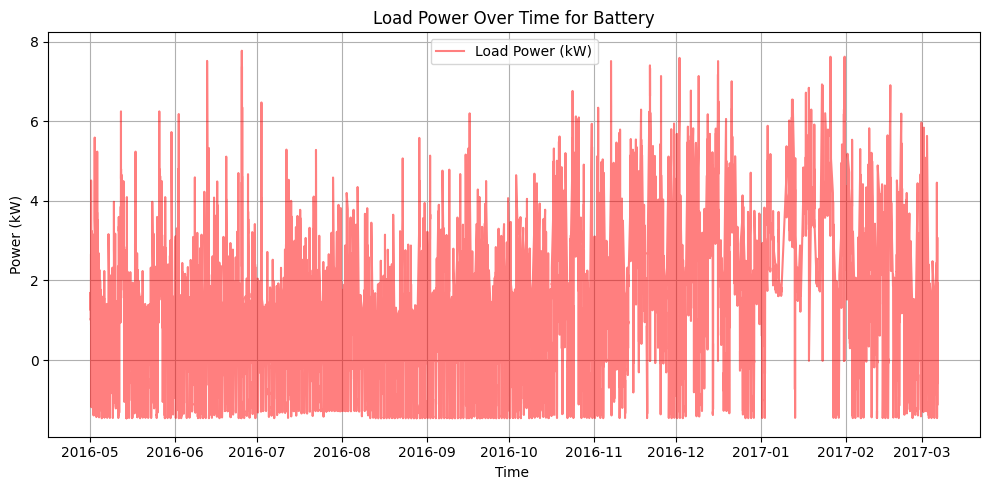

In [4]:
df_cut = df[(df["E_pv_interval_kwh"] > 0) & (df["cet_cest_timestamp"] > "2016-05")].copy()
df_cut["P_pv_inst_kW"] = df_cut["E_pv_interval_kwh"] / dt
df_cut["P_load_inst_kW"] = df_cut["E_load_interval_kwh"] / dt - df_cut["P_pv_inst_kW"]

df_cut["P_pv_inst_kW"] = 0.0  

max_power = max(df_cut["P_load_inst_kW"])
print(f"Potência máxima da carga: {max_power:.2f} kW")

plt.figure(figsize=(10, 5))
plt.plot(df_cut["cet_cest_timestamp"], df_cut["P_load_inst_kW"], label="Load Power (kW)", color='red', alpha=0.5)
plt.xlabel("Time ")
plt.ylabel("Power (kW)")
plt.title("Load Power Over Time for Battery")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

chemistries = ["LFP", "NMC", "LTO", "Sodium"]

In [5]:
# Calcular a potência RMS
power_rms = np.sqrt(np.mean(df_cut["P_load_inst_kW"]**2))

print(f"Potência RMS da carga: {power_rms:.2f} kW")
# Dimensionar a bateria para suportar essa potência ao maximo c_rate contínuo
bat_energy_kWh_cont = {c: 0 for c in chemistries}
n_cells_cont = {c: 0 for c in chemistries}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    bat_energy_kWh_cont[chem] = power_rms/cell_row["MaxContinuousDischargeRate"]
    n_cells_cont[chem] = int((bat_energy_kWh_cont[chem]*1000) / cell_row["E_cell_Wh"])
    print(f"Energia da bateria dimensionada para {cell_row['MaxContinuousDischargeRate']} C continuo para {chem}: {bat_energy_kWh_cont[chem]:.2f} kWh, Número de células: {n_cells_cont[chem]}")

Potência RMS da carga: 1.91 kW
Energia da bateria dimensionada para 0.5 C continuo para LFP: 3.82 kWh, Número de células: 23
Energia da bateria dimensionada para 1.0 C continuo para NMC: 1.91 kWh, Número de células: 4
Energia da bateria dimensionada para 1.0 C continuo para LTO: 1.91 kWh, Número de células: 13
Energia da bateria dimensionada para 0.5 C continuo para Sodium: 3.82 kWh, Número de células: 26


In [6]:
bat_energy_kWh_peak = {c: 0 for c in chemistries}
n_cells_peak = {c: 0 for c in chemistries}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    max_power = max(df_cut["P_load_inst_kW"])
    print(f"Potência máxima da carga: {max_power:.2f} kW")
    bat_energy_kWh_peak[chem] = max_power/cell_row["PeakDischargeRate"]
    n_cells_peak[chem] = int((bat_energy_kWh_peak[chem]*1000) / cell_row["E_cell_Wh"])
    print(f"Energia da bateria dimensionada para {cell_row['PeakDischargeRate']} C pico para {chem}: {bat_energy_kWh_peak[chem]:.2f} kWh, Número de células: {n_cells_peak[chem]}")

Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 5 C pico para LFP: 1.55 kWh, Número de células: 9
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 3 C pico para NMC: 2.59 kWh, Número de células: 6
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 12 C pico para LTO: 0.65 kWh, Número de células: 4
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 5 C pico para Sodium: 1.55 kWh, Número de células: 10


In [7]:
bat_energy_kWh = {c: 0 for c in chemistries}
n_cells = {c: 0 for c in chemistries}
for chem in chemistries:
    if n_cells_cont[chem] > n_cells_peak[chem]:
        bat_energy_kWh[chem] = bat_energy_kWh_cont[chem]
        n_cells[chem] = n_cells_cont[chem]
    else:
        bat_energy_kWh[chem] = bat_energy_kWh_peak[chem]
        n_cells[chem] = n_cells_peak[chem]
    print(f"Energia da bateria final para {chem}: {bat_energy_kWh[chem]:.2f} kWh, Número de células: {n_cells[chem]}")

Energia da bateria final para LFP: 3.82 kWh, Número de células: 23
Energia da bateria final para NMC: 2.59 kWh, Número de células: 6
Energia da bateria final para LTO: 1.91 kWh, Número de células: 13
Energia da bateria final para Sodium: 3.82 kWh, Número de células: 26



--- Simulação de lifetime para cada química ---


--- Resultados para química: LFP ---
LFP: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


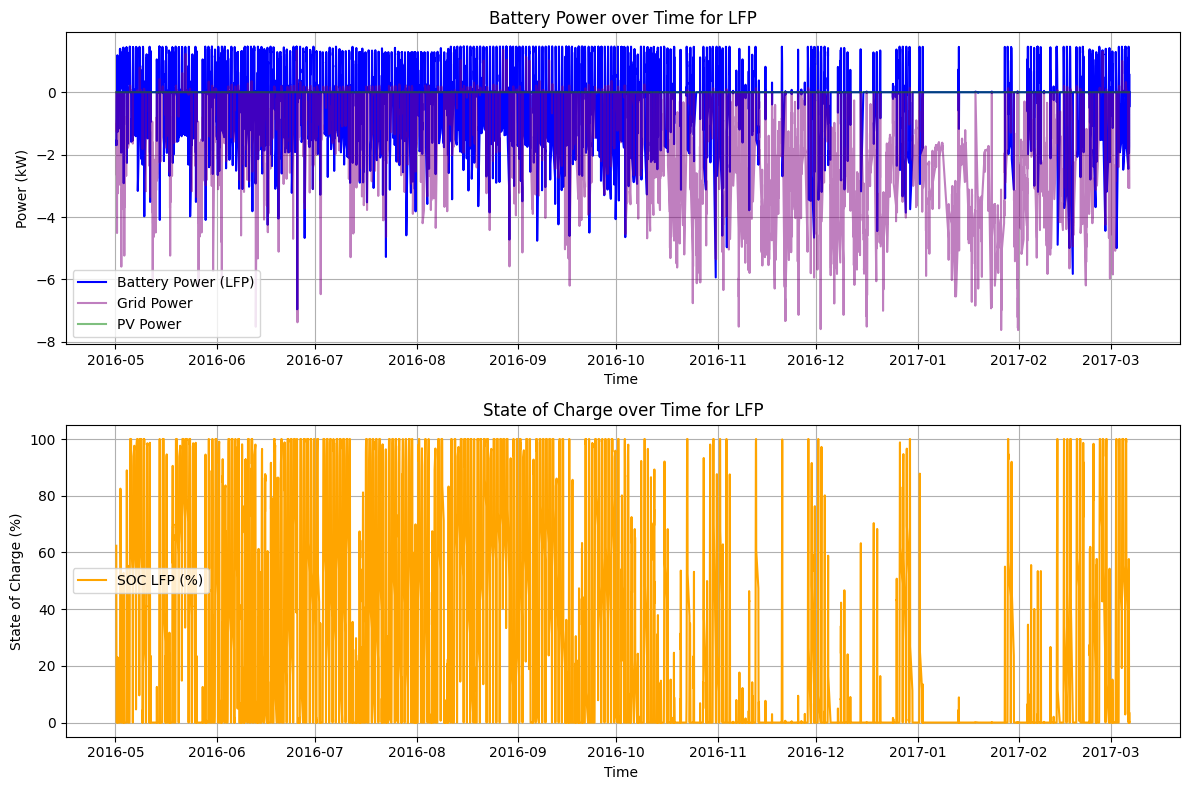

LFP: Lifetime equivalente: 57.8 anos, Fração de vida consumida: 6071.20%
  C-rate médio: 0.25, C-rate médio ligado: 0.25, C-rate máximo: 1.89
  Ciclos totais: 219.6, Ciclos por ano (assumindo 1 ano): 548.5


--- Resultados para química: NMC ---
NMC: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


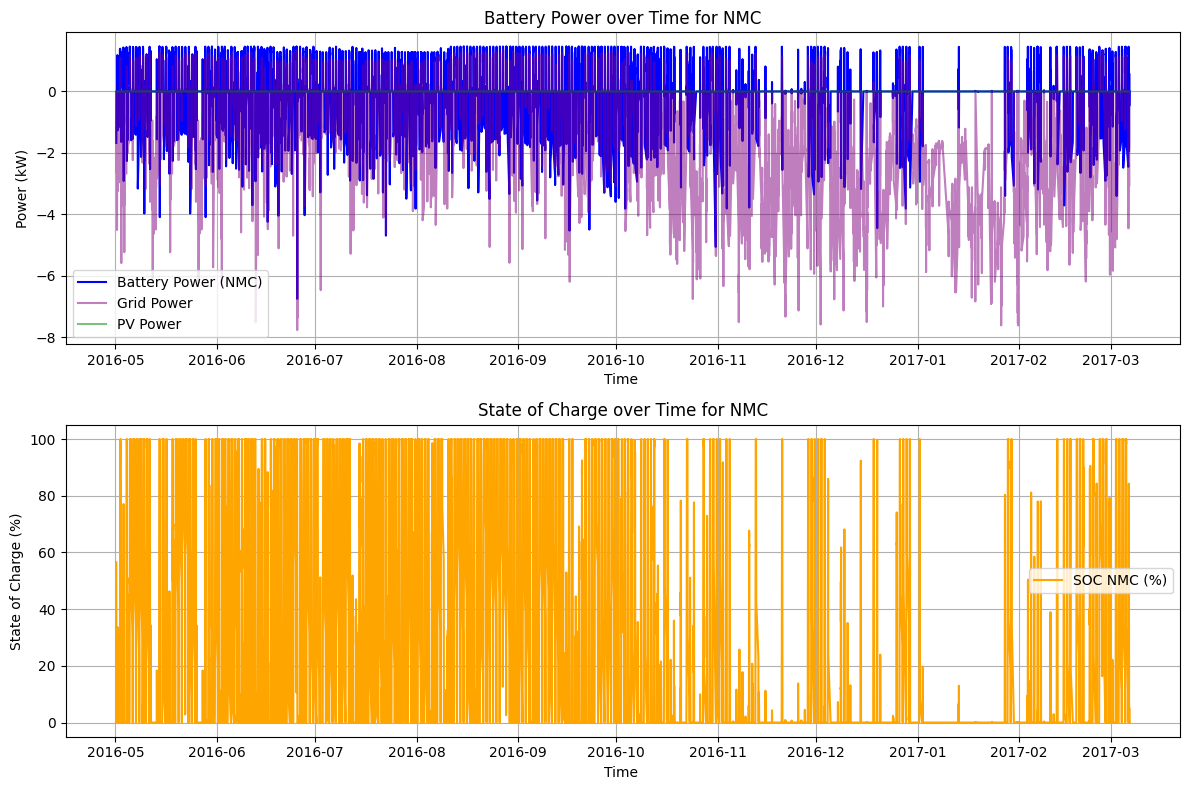

NMC: Lifetime equivalente: 38.0 anos, Fração de vida consumida: 9235.45%
  C-rate médio: 0.37, C-rate médio ligado: 0.37, C-rate máximo: 2.68
  Ciclos totais: 247.6, Ciclos por ano (assumindo 1 ano): 618.3


--- Resultados para química: LTO ---
LTO: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


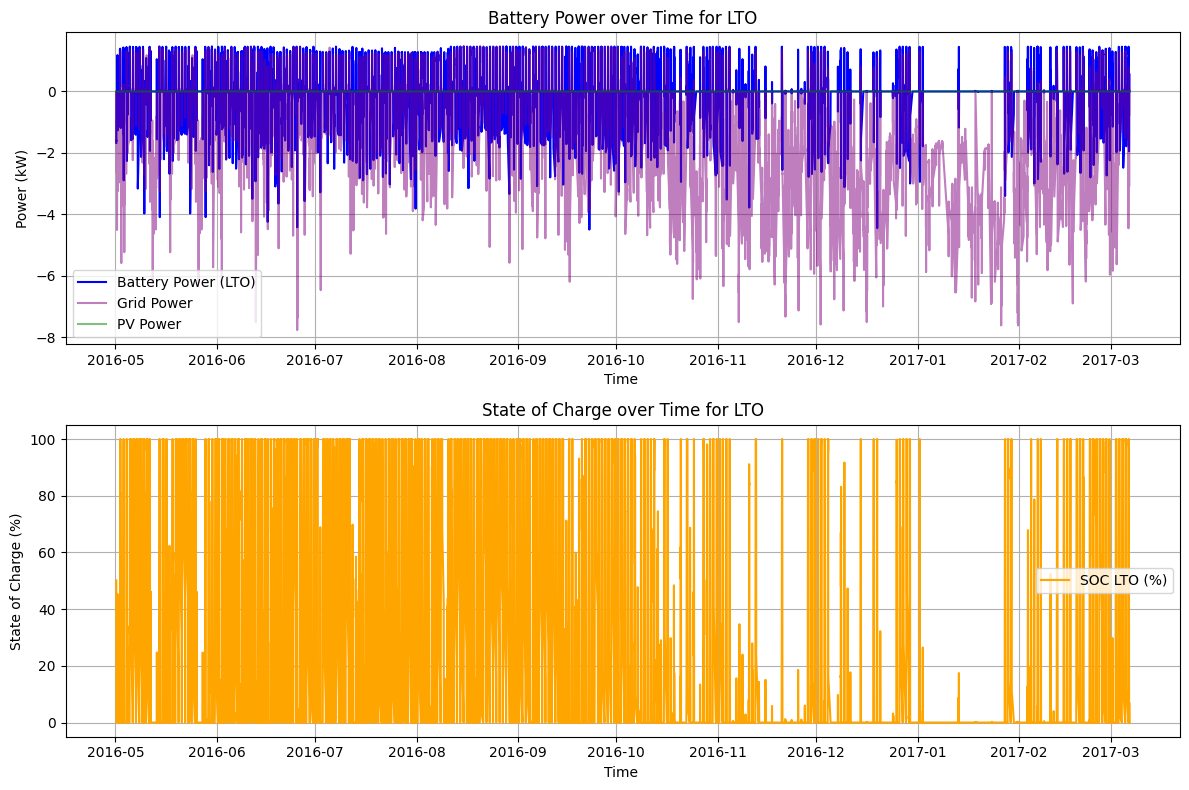

LTO: Lifetime equivalente: 19.0 anos, Fração de vida consumida: 18493.17%
  C-rate médio: 0.46, C-rate médio ligado: 0.46, C-rate máximo: 2.40
  Ciclos totais: 265.7, Ciclos por ano (assumindo 1 ano): 663.6


--- Resultados para química: Sodium ---
Sodium: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


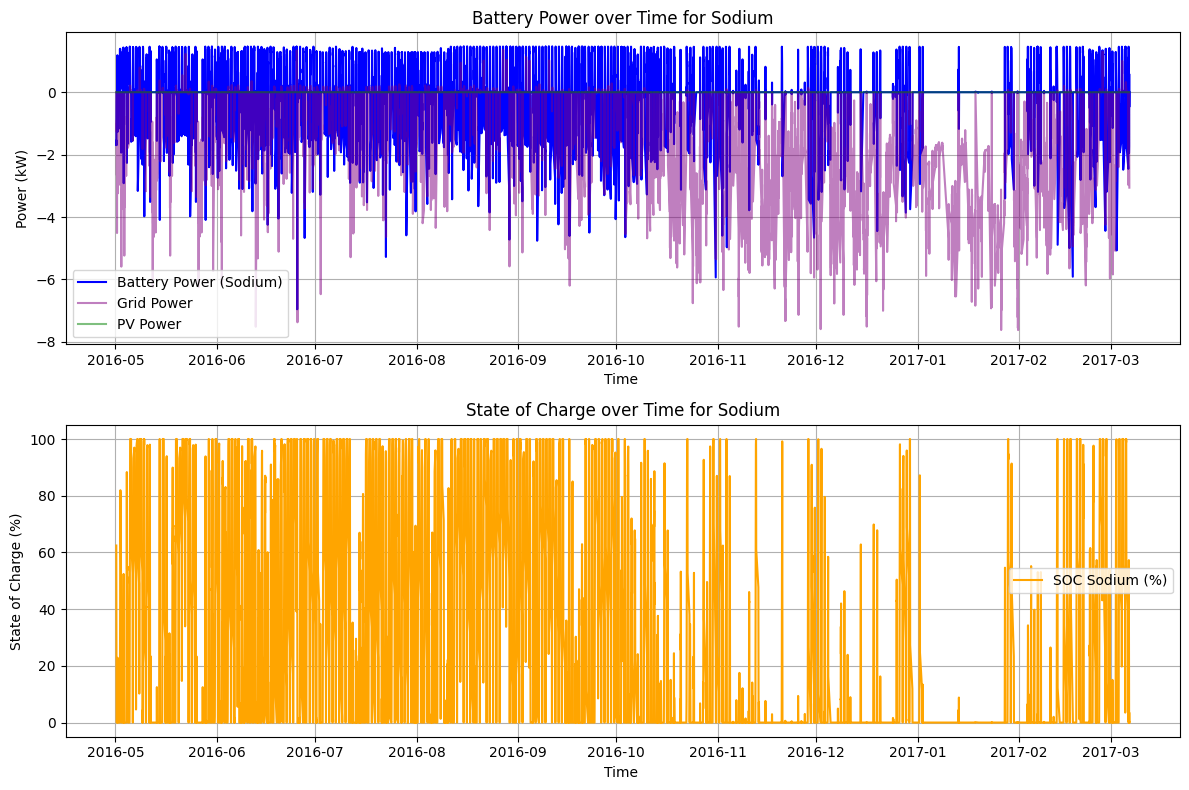

Sodium: Lifetime equivalente: 66.3 anos, Fração de vida consumida: 5293.05%
  C-rate médio: 0.24, C-rate médio ligado: 0.24, C-rate máximo: 1.88
  Ciclos totais: 218.8, Ciclos por ano (assumindo 1 ano): 546.6


In [8]:
print("\n--- Simulação de lifetime para cada química ---")
lifetime_years = {}
c_rate_max = {}
c_rate_mean = {}
bat_df = {}
sim_time_hours = len(df_cut) * dt
P_batt = {}
for chem in chemistries:
    print("\n")
    print(f"--- Resultados para química: {chem} ---")
    bat_df[chem] = get_battery_parameters({chem: n_cells[chem]}, cells_df)
    P_batt[chem], P_grid, P_batt_all, SOC_hist = dispatch_battery(df_cut, bat_df[chem], dt)
    P_pv = df_cut["P_pv_inst_kW"].values


    plt.figure(figsize=(12, 8))

    # Plot 1: Battery Power
    plt.subplot(2, 1, 1)
    plt.plot(df_cut["cet_cest_timestamp"], P_batt[chem][chem], label=f"Battery Power ({chem})", color='blue')
    plt.plot(df_cut["cet_cest_timestamp"], P_grid, label="Grid Power", color='purple', alpha=0.5)
    plt.plot(df_cut["cet_cest_timestamp"], P_pv, label="PV Power", color='green', alpha=0.5)
    plt.xlabel("Time ")
    plt.ylabel("Power (kW)")
    plt.title(f"Battery Power over Time for {chem}")
    plt.legend()
    plt.grid()

    # Plot 2: SOC (%)
    plt.subplot(2, 1, 2)
    soc = SOC_hist[chem]
    soc_percent = soc / (bat_df[chem].loc[bat_df[chem]["Composition"] == chem, "E_total_Wh"].values[0] / 1000) * 100
    plt.plot(df_cut["cet_cest_timestamp"], soc_percent, label=f"SOC {chem} (%)", color='orange')
    plt.xlabel("Time ")
    plt.ylabel("State of Charge (%)")
    plt.title(f"State of Charge over Time for {chem}")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


    damage, c_rate_mean[chem], c_rate_mean_on, c_rate_max[chem], cycles = compute_damage(P_batt[chem], bat_df[chem], dt, alpha)
    row = bat_df[chem][bat_df[chem]["Composition"] == chem].iloc[0]
    life_fraction = damage[chem] 
    sim_time_hours = len(df_cut) * dt
    lifetime_years[chem] = sim_time_hours / life_fraction 
    print(f"{chem}: Lifetime equivalente: {lifetime_years[chem]:.1f} anos, Fração de vida consumida: {life_fraction:.2%}")
    print(f"  C-rate médio: {c_rate_mean[chem][chem]:.2f}, C-rate médio ligado: {c_rate_mean_on[chem]:.2f}, C-rate máximo: {c_rate_max[chem][chem]:.2f}")
    print(f"  Ciclos totais: {cycles[chem]:.1f}, Ciclos por ano (assumindo 1 ano): {cycles[chem]/(len(df_cut)*dt/8760):.1f}")

In [9]:
price_battery = {}
price_battery_per_year = {}
price_battery_per_year_per_energy = {}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    price_per_kwh = cell_row["Price"]
    price_battery[chem] = price_per_kwh*bat_energy_kWh[chem]
    price_battery_per_year[chem] = price_battery[chem]/lifetime_years[chem]
    # Custo anual por kWh útil fornecido ao longo da vida útil
    # Integração da energia total fornecida pela bateria (em kWh)
    energia_total_kWh = np.sum(np.abs(P_batt[chem][chem])) * dt  # P_batt em kW, dt em horas
    price_battery_per_year_per_energy[chem] = price_battery[chem] / (energia_total_kWh*(lifetime_years[chem]/(sim_time_hours/(24*365))))
    
    print(f" {chem}: Preço da bateria: {price_battery[chem]:.2f} €, Custo anual: {price_battery_per_year[chem]:.2f} €, Custo anual por kWh útil: {price_battery_per_year_per_energy[chem]:.4f} €/kWh")

 LFP: Preço da bateria: 343.47 €, Custo anual: 5.95 €, Custo anual por kWh útil: 0.0015 €/kWh
 NMC: Preço da bateria: 233.14 €, Custo anual: 6.14 €, Custo anual por kWh útil: 0.0020 €/kWh
 LTO: Preço da bateria: 858.68 €, Custo anual: 45.28 €, Custo anual por kWh útil: 0.0182 €/kWh
 Sodium: Preço da bateria: 228.98 €, Custo anual: 3.46 €, Custo anual por kWh útil: 0.0009 €/kWh


In [10]:
from IPython.display import display, Latex
df = pd.DataFrame({
    'Química': chemistries,
    'Custo da Bateria (€)': [price_battery[chem] for chem in chemistries],
    'Custo Anual da Bateria (€)': [price_battery_per_year[chem] for chem in chemistries],
    'Custo Anual por kWh Útil (€ / kWh)': [
        price_battery_per_year_per_energy[chem]
        for chem in chemistries
    ],
})

# Gera LaTeX da tabela sem índice
latex_table = df.to_latex(index=False, escape=False, column_format='lcccccc')

# Envolve em \small para reduzir a fonte
latex_table = r'\begin{small}' + '\n' + latex_table + '\n' + r'\end{small}'

# Display como LaTeX interpretado
display(Latex(latex_table))

<IPython.core.display.Latex object>

In [11]:
print("\n--- Resumo dos resultados de lifetime ---")
print(f"{'Química':<10} {'Lifetime (anos)':<20} {'Bateria Energy (kWh)':<25} {'Número de Células':<20} {'C-rate Máximo':<15} {'C-rate Médio':<15}")
for chem in chemistries:
    print(f"{chem:<10} {lifetime_years[chem]:<20.1f} {bat_energy_kWh[chem]:<25.2f} {n_cells[chem]:<20} {c_rate_max[chem][chem]:<15.2f} {c_rate_mean[chem][chem]:<15.2f}")


--- Resumo dos resultados de lifetime ---
Química    Lifetime (anos)      Bateria Energy (kWh)      Número de Células    C-rate Máximo   C-rate Médio   
LFP        57.8                 3.82                      23                   1.89            0.25           
NMC        38.0                 2.59                      6                    2.68            0.37           
LTO        19.0                 1.91                      13                   2.40            0.46           
Sodium     66.3                 3.82                      26                   1.88            0.24           


In [12]:
from IPython.display import display, Latex
import pandas as pd

df = pd.DataFrame({
    'Química': chemistries,
    'Lifetime (anos)': [lifetime_years[chem] for chem in chemistries],
    'Bateria Energy (kWh)': [bat_energy_kWh[chem] for chem in chemistries],
    'Número de Células': [n_cells[chem] for chem in chemistries],
    'C-rate Máximo': [c_rate_max[chem][chem] for chem in chemistries],
    'C-rate Médio': [c_rate_mean[chem][chem] for chem in chemistries]
})

# Gera LaTeX da tabela sem índice
latex_table = df.to_latex(index=False, escape=False, column_format='lcccccc')

# Envolve em \small para reduzir a fonte
latex_table = r'\begin{small}' + '\n' + latex_table + '\n' + r'\end{small}'

# Display como LaTeX interpretado
display(Latex(latex_table))

<IPython.core.display.Latex object>